Using cache found in /home/najo/.cache/torch/hub/intel-isl_MiDaS_master


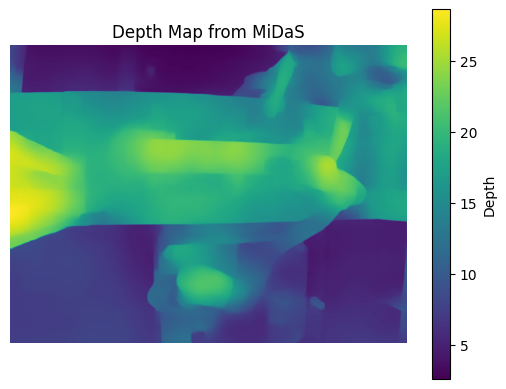

In [7]:
import torch
import cv2
import matplotlib.pyplot as plt
from torchvision.transforms import Compose, Normalize, ToTensor
from PIL import Image
import numpy as np

# TIFF 이미지 파일 경로
image_path = "/home/najo/NAS/DIP/datasets/Robot_data/Basler_acA1300-30gc__24051641__20240911_131710002_0488.tiff"

# MiDaS 모델 로드
model_type = "DPT_Large"  # 또는 "MiDaS_small" (경량화된 모델)
midas = torch.hub.load("intel-isl/MiDaS", model_type)
midas.eval()

# MiDaS 변환 설정
midas_transforms = Compose([
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# TIFF 이미지 읽기 및 변환
img = Image.open(image_path).convert("RGB")  # TIFF 이미지를 RGB로 변환
img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)  # PIL 이미지를 OpenCV 형식으로 변환

# 이미지 변환
input_batch = midas_transforms(img).unsqueeze(0)

# 깊이 추정
with torch.no_grad():
    depth_map = midas(input_batch)
    depth_map = depth_map.squeeze().cpu().numpy()

# 깊이 맵 시각화
plt.imshow(depth_map, cmap="viridis")
plt.colorbar(label="Depth")
plt.title("Depth Map from MiDaS")
plt.axis('off')
plt.show()
